#### U24AI070
#### Dev Sangam Kumar

### Installing Dependencies

In [ ]:
!pip install automata-lib
!pip install pandas
!pip install graphviz
!pip install colormath
!pip install jupyterlab
!pip install visual-automata
!apt-get install -y graphviz-dev
!pip install coloraide pygraphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for colormath: filename=colormath-3.0.0-py3-none-any.whl size=39405 sha256=abba77eead77e14958e4e512df33c3c6490ae6da6ddccb8236d8f7c16d7b781e
  Stored in directory: /root/.cache/pip/wheels/9a/32/6a/605739a172d8112031c9875d744aef91709f00de9b3bbb9274
Successfully built colormath
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 122.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for forbiddenfruit: filename=forbiddenfruit-0.1.4-py3-none

## Question 1: DFA for simplified English words

### Define DFA

In [ ]:
from automata.fa.dfa import DFA
from visual_automata.fa.dfa import VisualDFA
import string

lowercase = set(string.ascii_lowercase)
uppercase = set(string.ascii_uppercase)
full_alphabet = set(string.ascii_letters)

dfa = DFA(
    states={'q0', 'q1', 'q_reject'},
    input_symbols=full_alphabet,
    transitions={
        'q0': {char: 'q1' for char in full_alphabet},
        'q1': {**{char: 'q1' for char in lowercase},
               **{char: 'q_reject' for char in uppercase},
               },

        'q_reject': {char: 'q_reject' for char in full_alphabet}
    },
    initial_state='q0',
    final_states={'q1'}
)


### helper function to check acceptance

In [ ]:
def check_word_with_dfa(word):
    if not word:
        return "Not Accepted"
    try:
        if dfa.accepts_input(word):
            return "Accepted"
        else:
            return "Not Accepted"
    except Exception:
        return "Not Accepted"

### Testing DFA

In [ ]:
test_words = [
    "Cat", "D", "apple",
    "cAT", "DOG", "a1"
]

for w in test_words:
    print(f"'{w}': {check_word_with_dfa(w)}")


'Cat': Accepted
'D': Accepted
'apple': Accepted
'cAT': Not Accepted
'DOG': Not Accepted
'a1': Not Accepted


### DFA Visulization

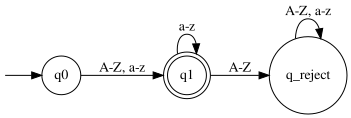

In [ ]:
import graphviz
from collections import defaultdict
import string

lowercase = set(string.ascii_lowercase)
uppercase = set(string.ascii_uppercase)
full_alphabet = set(string.ascii_letters)
ascii_chars=set(string.printable)
non_alphabet=ascii_chars-full_alphabet
non_alphabet_with_uppercase = non_alphabet.union(uppercase)


dot = graphviz.Digraph()
dot.attr(rankdir='LR')

for state in dfa.states:
    shape = 'doublecircle' if state in dfa.final_states else 'circle'
    dot.node(state, shape=shape)

dot.node('', shape='none', width='0')
dot.edge('', dfa.initial_state)

coalesced_transitions = defaultdict(list)
for start_state, transitions in dfa.transitions.items():
    for symbol, end_state in transitions.items():
        coalesced_transitions[(start_state, end_state)].append(symbol)

for (start, end), symbols in coalesced_transitions.items():
    symbol_set = set(symbols)
    if symbol_set == full_alphabet:
        label = 'A-Z, a-z'
    elif symbol_set == set(string.ascii_lowercase):
        label = 'a-z'
    elif symbol_set == set(string.ascii_uppercase):
        label = 'A-Z'
    elif symbol_set == ascii_chars:
        label = 'ASCII char'
    elif symbol_set == non_alphabet:
        label = 'non-alphabet char'
    elif symbol_set == non_alphabet_with_uppercase:
        label = 'A-Z, non-alphabet char'
    else:
        label = ', '.join(sorted(symbols))
    dot.edge(start, end, label=label)

display(dot)

## Question 2: FST to generate the morph/grammatical features

### Define states, input / output symbols, and transitions

In [ ]:
states=set(["q_base", "q_es0", "q_es1", "q_es2", "q_ies1", "q_ies2", "q_ies3", "q_back", "q_c", "q_s", "q_ss", "q_y", "q_ys", "q_reject", "q_accept"])
input_symbols= set(string.ascii_lowercase) | {'<EOW>'}
output_symbols=set(string.ascii_lowercase) | {'+','N','S','G', 'P','L', ''}
initial_state="q_base"
final_states={"q_accept"}

q_base_other= { ("q_base", char):("q_base", char) for char in input_symbols - {'<EOW>', "x", "z", 'c', "y", "i", "s"}}
q_es0_other= { ("q_es0", char):("q_base", char) for char in input_symbols - {'e', '<EOW>'}}
q_es1_other= { ("q_es1", char):("q_base", "e"+char) for char in input_symbols - {'s', '<EOW>'}}
q_es2_other= { ("q_es2", char):("q_base", "es"+char) for char in input_symbols - {'<EOW>'}}
q_back_other= { ("q_back", char):("q_base", char) for char in input_symbols - {'<EOW>'}}
q_c_other= { ("q_c", char):("q_base", char) for char in input_symbols - {'h', '<EOW>'}}
q_s_other= { ("q_s", char):("q_base", "s"+char) for char in input_symbols - {'h', '<EOW>', 's'}}
q_ss_other= { ("q_ss", char):("q_base", char) for char in input_symbols - {'<EOW>'}}
q_y_other= { ("q_y", char):("q_base", char) for char in input_symbols - {'s', '<EOW>'}}
q_ys_other= { ("q_ys", char):("q_base", char) for char in input_symbols - {'<EOW>'}}
q_ies1_other= { ("q_ies1", char):("q_base", "i"+char) for char in input_symbols - {'e', '<EOW>'}}
q_ies2_other= { ("q_ies2", char):("q_base", "ie"+char) for char in input_symbols - {'s', '<EOW>'}}
q_ies3_other= { ("q_ies3", char):("q_base", "y"+char) for char in input_symbols - {'<EOW>'}}

transitions={
    ("q_base", "x"):("q_es0", "x"),
    ("q_base", "z"):("q_es0", "z"),
    ("q_base", "c"):("q_c", "c"),
    ("q_base", "s"):("q_s", ""),
    ("q_base", "y"):("q_y", "y"),
    ("q_base", "i"):("q_ies1", ""),
    ("q_base", "<EOW>"):("q_accept", "+N+SG"),

    ("q_es0", "e"):("q_es1", ""),
    ("q_es0", "s"):("q_back", "s"),
    ("q_es0", "<EOW>"): ("q_accept", "+N+SG"),

    ("q_back", "<EOW>"):("q_reject", ""),

    ("q_es1", "s"):("q_es2", ""),
    ("q_es1", "<EOW>"):("q_accept", "e+N+SG"),

    ("q_es2", "<EOW>"):("q_accept", "+N+PL"),

    ("q_c", "h"):("q_es0", "h"),
    ("q_c", "<EOW>"):("q_accept", "+N+SG"),

    ("q_s", "h"):("q_es0", "sh"),
    ("q_s", "s"): ("q_ss", "ss"),
    ("q_s", "<EOW>"):("q_accept", "+N+PL"),

    ("q_ss", "<EOW>"):("q_accept", "+N+SG"),

    ("q_y", "s"):("q_ys", "s"),
    ("q_y", "<EOW>"):("q_accept", "+N+SG"),

    ("q_ys", "<EOW>"):("q_reject", ""),

    ("q_ies1", "e"):("q_ies2", ""),
    ("q_ies1", "<EOW>"):("q_accept", "i+N+SG"),

    ("q_ies2", "<EOW>"):("q_accept", "ie+N+SG"),
    ("q_ies2", "s"):("q_ies3", ""),

    ("q_ies3", "<EOW>"):("q_accept", "y+N+PL"),
}


all_transitions={
                  **q_base_other,
                  **q_es0_other,
                  **q_es1_other,
                  **q_es2_other,
                  **q_back_other,
                  **q_c_other,
                  **q_s_other,
                  **q_ss_other,
                  **q_y_other,
                  **q_ys_other,
                  **q_ies1_other,
                  **q_ies2_other,
                  **q_ies3_other,
                  **transitions
                 }


### Define FST Class

In [ ]:
class FST():
    def __init__(self, states, input_symbols, output_symbols, initial_state, final_states, transitions):
        self.states=states
        self.input_symbols=input_symbols
        self.output_symbols=output_symbols
        self.initial_state=initial_state
        self.final_states=final_states
        self.transitions=transitions

        if(not self.__validate__()):
            raise Exception("Invalid FST")

    def __validate__(self):
        if self.initial_state not in self.states:
            return False
        for state in self.final_states:
            if state not in self.states:
                return False
        for (start, char), (end, out_char) in self.transitions.items():
            if start not in self.states:
                return False
            if end not in self.states:
                return False
            if char not in self.input_symbols:
                return False
            for out_c in out_char:
                if out_c not in self.output_symbols:
                    return False
        return True

    def format_word(self, word):
        if not word:
            return ["-1"]
        word_lst= list(word)
        word_lst.append("<EOW>")
        return word_lst

    def parse(self, word):
        state=self.initial_state
        output=[]
        word_lst=self.format_word(word)
        for char in word_lst:
            if char not in self.input_symbols:
                return "Invalid Word"
            key=(state, char)
            if key in self.transitions:
                state, out_char=self.transitions[key]
                output.append(out_char)
            else:
                return "Invalid Word"
        if state in self.final_states:
            return "".join(output)
        else:
            return "Invalid Word"

### FST on test words

In [ ]:
fst = FST(states, input_symbols, output_symbols, initial_state, final_states, all_transitions)
test_words = ["foxes", "fox", "foxs", "watches", "flies", "fly", "bags", "bag"]

for word in test_words:
    print(f"{word:10}= {fst.parse(word)}")

foxes     = fox+N+PL
fox       = fox+N+SG
foxs      = Invalid Word
watches   = watch+N+PL
flies     = fly+N+PL
fly       = fly+N+SG
bags      = bag+N+PL
bag       = bag+N+SG


### Parse `brown_nouns.txt`

In [ ]:
input_path = '/content/brown_nouns.txt'
output_path = '/content/brown_nouns_results.txt'

with open(input_path, 'r') as f:
    nouns = [line.strip() for line in f if line.strip()]

results = [fst.parse(n) for n in nouns]

with open(output_path, 'w') as f:
    for res in results:
        f.write(res + '\n')

print(f"Successfully processed {len(results)} nouns.")
print(f"Features saved to: {output_path}")

print("\nPreview of output:")
for line in results[:10]:
    print(line)

Successfully processed 202793 nouns.
Features saved to: /content/brown_nouns_results.txt

Preview of output:
investigation+N+SG
primary+N+SG
election+N+SG
evidence+N+SG
irregularity+N+PL
place+N+SG
jury+N+SG
presentment+N+PL
charge+N+SG
election+N+SG
